# Exploração inicial do dataset Sparkov

Este notebook realiza a exploração inicial do arquivo `fraudTrain.csv` com **pandas**, **numpy** e **matplotlib**.

## Objetivos

- compreender a estrutura e a qualidade dos dados;
- medir o desbalanceamento de `is_fraud`;
- explorar valor, tempo, categoria, localização e perfil das transações;
- criar gráficos em alta resolução para a documentação do TCC;
- levantar hipóteses sem treinar modelos ou aplicar balanceamento.

> O dataset Sparkov é sintético. As análises devem ser interpretadas como características desta base, não como conclusões universais sobre fraudes reais.

## 1. Bibliotecas e caminhos

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

caminho_csv = [
    Path("../raw/fraudTrain.csv")
]
DATA_PATH = next((p for p in caminho_csv if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Ajuste DATA_PATH p                          ara o local de fraudTrain.csv")

FIGURES_PATH = Path("../outputs/figures/01_eda_sparkov")
TABLES_PATH = Path("../outputs/tables/01_eda_sparkov")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
TABLES_PATH.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_PATH.resolve())

Dataset: /home/lucas/Documentos/tcc_ccard_fraud/raw/fraudTrain.csv


In [9]:
def finalizar_grafico(nome):
    plt.tight_layout()
    caminho = FIGURES_PATH / nome
    plt.savefig(caminho, dpi=300, bbox_inches="tight")
    plt.show()
    print("Salvo em:", caminho)


def taxa_por_grupo(dados, coluna, minimo=1):
    resumo = (dados.groupby(coluna, dropna=False)
              .agg(total_transacoes=("is_fraud", "size"),
                   total_fraudes=("is_fraud", "sum"))
              .reset_index())
    resumo["taxa_fraude_percentual"] = (
        resumo["total_fraudes"] / resumo["total_transacoes"] * 100
    )
    return resumo[resumo["total_transacoes"] >= minimo].copy()

## 2. Carregamento

In [10]:
dtypes = {
    "cc_num": "string", "trans_num": "string", "zip": "string",
    "merchant": "string", "category": "category", "gender": "category",
    "state": "category", "first": "string", "last": "string",
    "street": "string", "city": "string", "job": "string"
}

df = pd.read_csv(
    DATA_PATH,
    dtype=dtypes,
    parse_dates=["trans_date_trans_time", "dob"]
)

colunas_indice = [c for c in df.columns if str(c).startswith("Unnamed:")]
if colunas_indice:
    df = df.drop(columns=colunas_indice)

print(f"Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

Dimensões: 1,296,675 linhas × 22 colunas


In [12]:
len(df)

1296675

In [11]:
df.head(5)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0


In [7]:
print(df.head(5))

  trans_date_trans_time            cc_num                            merchant  \
0   2019-01-01 00:00:18  2703186189652095          fraud_Rippin, Kub and Mann   
1   2019-01-01 00:00:44      630423337322     fraud_Heller, Gutmann and Zieme   
2   2019-01-01 00:00:51    38859492057661                fraud_Lind-Buckridge   
3   2019-01-01 00:01:16  3534093764340240  fraud_Kutch, Hermiston and Farrell   
4   2019-01-01 00:03:06   375534208663984                 fraud_Keeling-Crist   

        category      amt      first     last gender  \
0       misc_net   4.9700   Jennifer    Banks      F   
1    grocery_pos 107.2300  Stephanie     Gill      F   
2  entertainment 220.1100     Edward  Sanchez      M   
3  gas_transport  45.0000     Jeremy    White      M   
4       misc_pos  41.9600      Tyler   Garcia      M   

                         street            city state    zip     lat  \
0                561 Perry Cove  Moravian Falls    NC  28654 36.0788   
1  43039 Riley Greens Suite 393 

## 3. Estrutura, tipos e cardinalidade

In [4]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  string        
 2   merchant               1296675 non-null  string        
 3   category               1296675 non-null  category      
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  string        
 6   last                   1296675 non-null  string        
 7   gender                 1296675 non-null  category      
 8   street                 1296675 non-null  string        
 9   city                   1296675 non-null  string        
 10  state                  1296675 non-null  category      
 11  zip                    1296675 non-null  string        
 12  lat                    12966

In [5]:
estrutura = pd.DataFrame({
    "coluna": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "nulos": df.isna().sum().values,
    "percentual_nulos": df.isna().mean().values * 100,
    "valores_unicos": df.nunique(dropna=True).values,
}).sort_values(["percentual_nulos", "valores_unicos"], ascending=[False, False])

estrutura.to_csv(TABLES_PATH / "estrutura_colunas.csv", index=False, encoding="utf-8-sig")
estrutura

,coluna,tipo,nulos,percentual_nulos,valores_unicos
17,trans_num,string,0,0.0000,1296675
20,merch_long,float64,0,0.0000,1275745
18,unix_time,int64,0,0.0000,1274823
0,trans_date_trans_time,datetime64[ns],0,0.0000,1274791
19,merch_lat,float64,0,0.0000,1247805
4,amt,float64,0,0.0000,52928
1,cc_num,string,0,0.0000,983
8,street,string,0,0.0000,983
11,zip,string,0,0.0000,970
13,long,float64,0,0.0000,969


## 4. Qualidade e consistência

In [6]:
total_nulos = int(df.isna().sum().sum())
duplicados_linha = int(df.duplicated().sum())
duplicados_transacao = int(df["trans_num"].duplicated().sum())

print(f"Valores nulos: {total_nulos:,}")
print(f"Linhas duplicadas: {duplicados_linha:,}")
print(f"trans_num duplicados: {duplicados_transacao:,}")

validacoes = pd.DataFrame({
    "verificacao": [
        "amt negativo", "lat fora de [-90,90]", "long fora de [-180,180]",
        "merch_lat fora de [-90,90]", "merch_long fora de [-180,180]",
        "is_fraud fora de {0,1}", "dob posterior à transação"
    ],
    "quantidade": [
        (df["amt"] < 0).sum(), (~df["lat"].between(-90, 90)).sum(),
        (~df["long"].between(-180, 180)).sum(),
        (~df["merch_lat"].between(-90, 90)).sum(),
        (~df["merch_long"].between(-180, 180)).sum(),
        (~df["is_fraud"].isin([0,1])).sum(),
        (df["dob"] > df["trans_date_trans_time"]).sum()
    ]
})
validacoes

Valores nulos: 0
Linhas duplicadas: 0
trans_num duplicados: 0


,verificacao,quantidade
0,amt negativo,0
1,"lat fora de [-90,90]",0
2,"long fora de [-180,180]",0
3,"merch_lat fora de [-90,90]",0
4,"merch_long fora de [-180,180]",0
5,"is_fraud fora de {0,1}",0
6,dob posterior à transação,0


## 5. Distribuição da variável-alvo

In [7]:
classes = df["is_fraud"].value_counts().sort_index()
legitimas = int(classes.get(0, 0))
fraudes = int(classes.get(1, 0))
percentual_fraudes = fraudes / len(df) * 100
razao = legitimas / fraudes

resumo_classes = pd.DataFrame({
    "classe": ["Legítima", "Fraude"],
    "quantidade": [legitimas, fraudes],
    "percentual": [legitimas/len(df)*100, percentual_fraudes]
})

print(f"Fraudes: {fraudes:,} ({percentual_fraudes:.6f}%)")
print(f"Razão: 1 fraude para {razao:,.2f} legítimas")
resumo_classes

Fraudes: 7,506 (0.578865%)
Razão: 1 fraude para 171.75 legítimas


,classe,quantidade,percentual
0,Legítima,1289169,99.4211
1,Fraude,7506,0.5789


In [13]:
len(df)

1296675

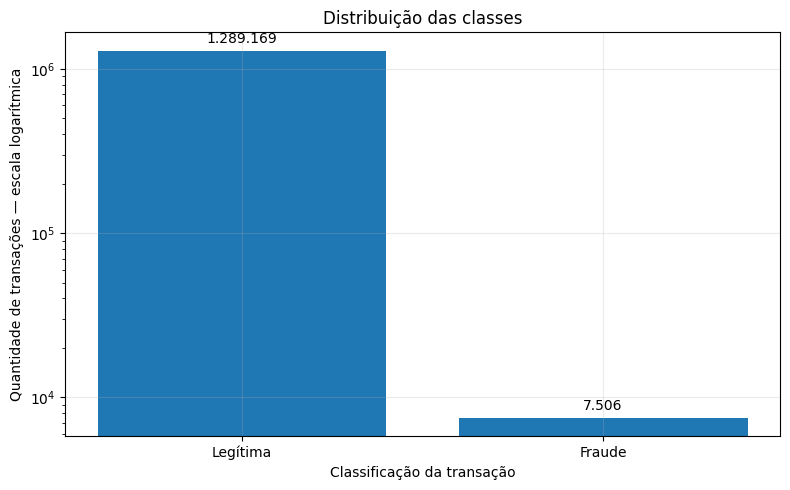

Salvo em: ../outputs/figures/01_eda_sparkov/01_distribuicao_classes_log.png


In [8]:
plt.figure(figsize=(8,5))
barras = plt.bar(["Legítima", "Fraude"], [legitimas, fraudes])
plt.yscale("log")
plt.title("Distribuição das classes")
plt.xlabel("Classificação da transação")
plt.ylabel("Quantidade de transações — escala logarítmica")
for barra, valor in zip(barras, [legitimas, fraudes]):
    plt.text(barra.get_x()+barra.get_width()/2, valor*1.12,
             f"{valor:,}".replace(",", "."), ha="center")
finalizar_grafico("01_distribuicao_classes_log.png")

In [9]:
acuracia_ingenua = legitimas / len(df)
print(f"Acurácia prevendo tudo como legítimo: {acuracia_ingenua:.4%}")
print(f"Fraudes identificadas: 0 de {fraudes:,}")
print("Recall da fraude: 0%")

Acurácia prevendo tudo como legítimo: 99.4211%
Fraudes identificadas: 0 de 7,506
Recall da fraude: 0%


## 6. Variáveis derivadas para exploração

In [10]:
df_eda = df.copy()
dt = df_eda["trans_date_trans_time"]
df_eda["ano_mes"] = dt.dt.to_period("M").astype(str)
df_eda["hora"] = dt.dt.hour
df_eda["dia_semana_num"] = dt.dt.dayofweek
df_eda["fim_de_semana"] = df_eda["dia_semana_num"].isin([5,6])
nomes_dias = {0:"Segunda",1:"Terça",2:"Quarta",3:"Quinta",4:"Sexta",5:"Sábado",6:"Domingo"}
df_eda["dia_semana"] = df_eda["dia_semana_num"].map(nomes_dias)

df_eda["idade"] = (
    dt.dt.year - df_eda["dob"].dt.year -
    (((dt.dt.month < df_eda["dob"].dt.month) |
      ((dt.dt.month == df_eda["dob"].dt.month) &
       (dt.dt.day < df_eda["dob"].dt.day))).astype(int))
)

inicio, fim = dt.min(), dt.max()
print("Início:", inicio)
print("Fim:", fim)
print("Duração:", fim-inicio)

Início: 2019-01-01 00:00:18
Fim: 2020-06-21 12:13:37
Duração: 537 days 12:13:19


## 7. Comportamento temporal

In [11]:
resumo_mes = (df_eda.groupby("ano_mes")
              .agg(total_transacoes=("is_fraud","size"),
                   total_fraudes=("is_fraud","sum"))
              .reset_index())
resumo_mes["participacao_transacoes_percentual"] = resumo_mes["total_transacoes"] / len(df_eda) * 100
resumo_mes["taxa_fraude_percentual"] = resumo_mes["total_fraudes"] / resumo_mes["total_transacoes"] * 100
resumo_mes

,ano_mes,total_transacoes,total_fraudes,participacao_transacoes_percentual,taxa_fraude_percentual
0,2019-01,52525,506,4.0507,0.9634
1,2019-02,49866,517,3.8457,1.0368
2,2019-03,70939,494,5.4708,0.6964
3,2019-04,68078,376,5.2502,0.5523
4,2019-05,72532,408,5.5937,0.5625
5,2019-06,86064,354,6.6373,0.4113
6,2019-07,86596,331,6.6783,0.3822
7,2019-08,87359,382,6.7372,0.4373
8,2019-09,70652,418,5.4487,0.5916
9,2019-10,68758,454,5.3026,0.6603


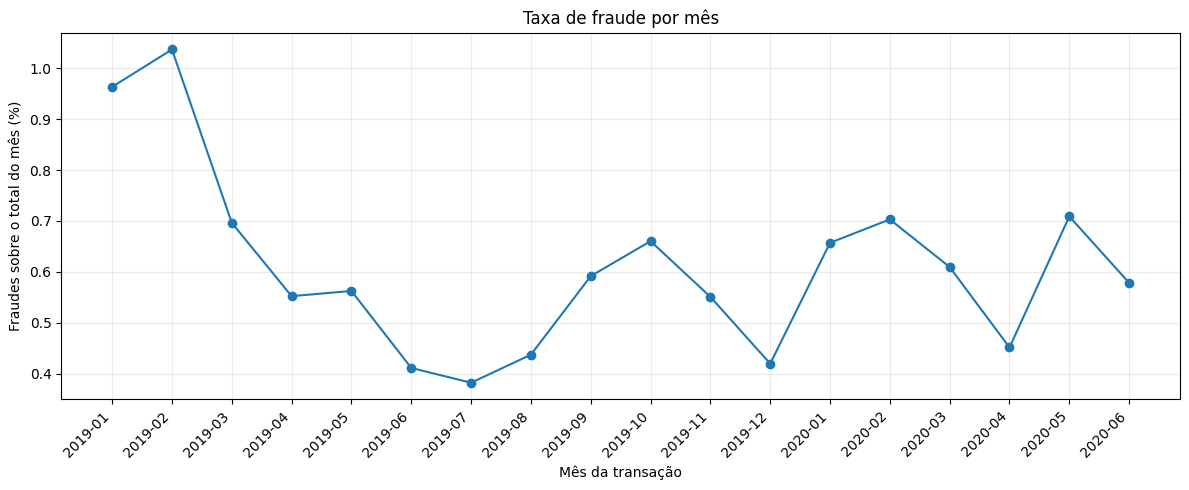

Salvo em: ../outputs/figures/01_eda_sparkov/02_taxa_fraude_por_mes.png


In [12]:
plt.figure(figsize=(12,5))
plt.plot(resumo_mes["ano_mes"], resumo_mes["taxa_fraude_percentual"], marker="o")
plt.title("Taxa de fraude por mês")
plt.xlabel("Mês da transação")
plt.ylabel("Fraudes sobre o total do mês (%)")
plt.xticks(rotation=45, ha="right")
finalizar_grafico("02_taxa_fraude_por_mes.png")

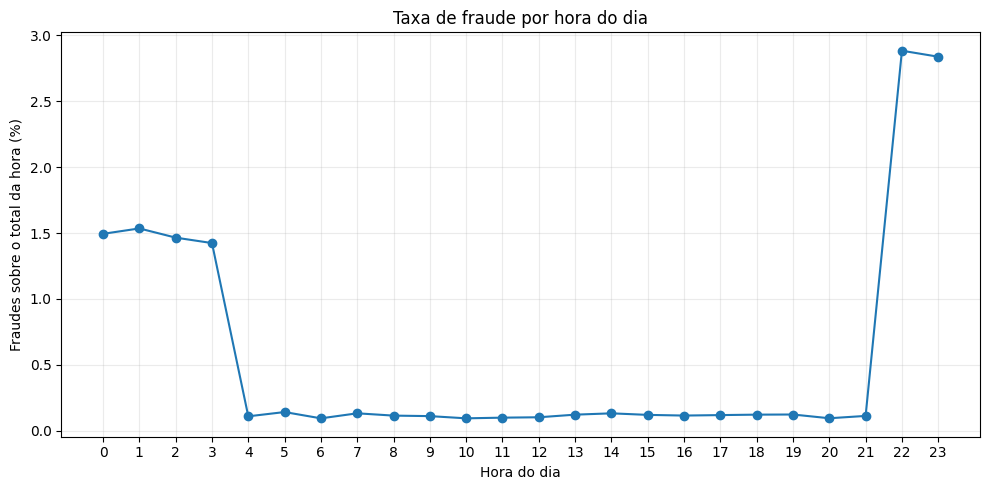

Salvo em: ../outputs/figures/01_eda_sparkov/03_taxa_fraude_por_hora.png


In [13]:
resumo_hora = (df_eda.groupby("hora")
               .agg(total_transacoes=("is_fraud","size"),
                    total_fraudes=("is_fraud","sum"))
               .reset_index())
resumo_hora["participacao_transacoes_percentual"] = resumo_hora["total_transacoes"] / len(df_eda) * 100
resumo_hora["taxa_fraude_percentual"] = resumo_hora["total_fraudes"] / resumo_hora["total_transacoes"] * 100

plt.figure(figsize=(10,5))
plt.plot(resumo_hora["hora"], resumo_hora["taxa_fraude_percentual"], marker="o")
plt.title("Taxa de fraude por hora do dia")
plt.xlabel("Hora do dia")
plt.ylabel("Fraudes sobre o total da hora (%)")
plt.xticks(range(24))
finalizar_grafico("03_taxa_fraude_por_hora.png")

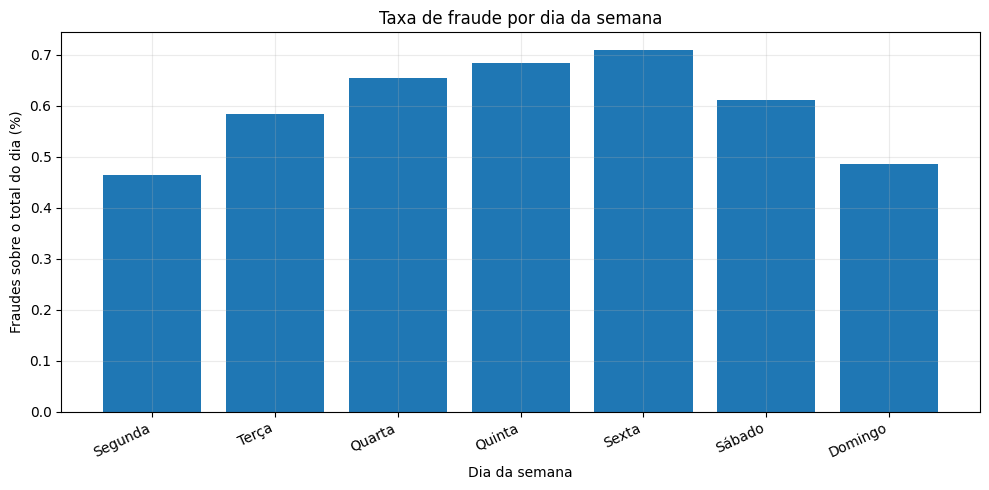

Salvo em: ../outputs/figures/01_eda_sparkov/04_taxa_fraude_por_dia_semana.png


In [14]:
ordem = ["Segunda","Terça","Quarta","Quinta","Sexta","Sábado","Domingo"]
resumo_dia = taxa_por_grupo(df_eda, "dia_semana").set_index("dia_semana").reindex(ordem).reset_index()

plt.figure(figsize=(10,5))
plt.bar(resumo_dia["dia_semana"], resumo_dia["taxa_fraude_percentual"])
plt.title("Taxa de fraude por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Fraudes sobre o total do dia (%)")
plt.xticks(rotation=25, ha="right")
finalizar_grafico("04_taxa_fraude_por_dia_semana.png")

## 8. Valor das transações (`amt`)

In [15]:
resumo_amt = df_eda.groupby("is_fraud")["amt"].agg(
    quantidade="count", media="mean", mediana="median", minimo="min",
    q1=lambda s: s.quantile(.25), q3=lambda s: s.quantile(.75),
    p95=lambda s: s.quantile(.95), p99=lambda s: s.quantile(.99), maximo="max"
)
resumo_amt.index = ["Legítima", "Fraude"]
resumo_amt

,quantidade,media,mediana,minimo,q1,q3,p95,p99,maximo
Legítima,1289169,67.6671,47.2800,1.0000,9.6100,82.5400,189.9000,486.3032,"28,948.9000"
Fraude,7506,531.3201,396.5050,1.0600,245.6625,900.8750,"1,083.9850","1,179.6900","1,376.0400"


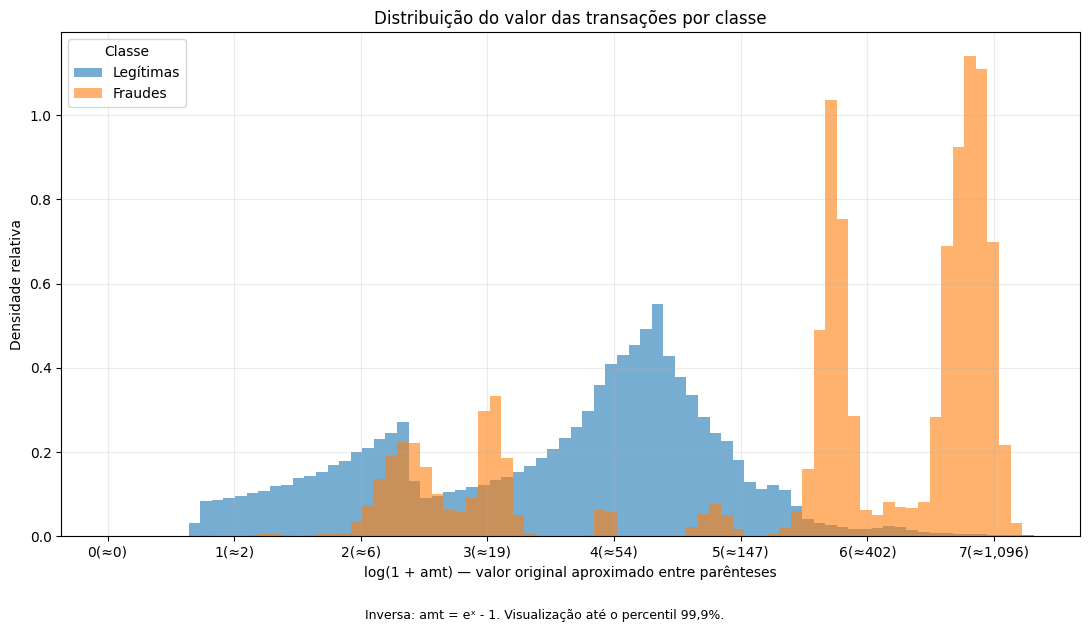

Salvo em: ../outputs/figures/01_eda_sparkov/05_distribuicao_amt_log.png


In [17]:
leg_log = np.log1p(df_eda.loc[df_eda["is_fraud"]==0, "amt"])
fraude_log = np.log1p(df_eda.loc[df_eda["is_fraud"]==1, "amt"])
limite = np.log1p(df_eda["amt"].quantile(.999))

plt.figure(figsize=(11,6))
plt.hist(leg_log, bins=80, range=(0,limite), density=True, alpha=.6, label="Legítimas")
plt.hist(fraude_log, bins=80, range=(0,limite), density=True, alpha=.6, label="Fraudes")
ticks = np.arange(0, int(np.floor(limite))+1)
plt.xticks(ticks, [f"{t}(≈{np.expm1(t):,.0f})" for t in ticks])
plt.title("Distribuição do valor das transações por classe")
plt.xlabel("log(1 + amt) — valor original aproximado entre parênteses")
plt.ylabel("Densidade relativa")
plt.legend(title="Classe")
plt.figtext(.5,-.04,"Inversa: amt = eˣ - 1. Visualização até o percentil 99,9%.",ha="center",fontsize=9)
finalizar_grafico("05_distribuicao_amt_log.png")

## 9. Categoria do estabelecimento

In [18]:
resumo_categoria = taxa_por_grupo(df_eda, "category").sort_values("taxa_fraude_percentual", ascending=False)
resumo_categoria

/tmp/ipykernel_22284/3765407447.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo = (dados.groupby(coluna, dropna=False)


,category,total_transacoes,total_fraudes,taxa_fraude_percentual
11,shopping_net,97543,1713,1.7561
8,misc_net,63287,915,1.4458
4,grocery_pos,123638,1743,1.4098
12,shopping_pos,116672,843,0.7225
2,gas_transport,131659,618,0.4694
9,misc_pos,79655,250,0.3139
3,grocery_net,45452,134,0.2948
13,travel,40507,116,0.2864
0,entertainment,94014,233,0.2478
10,personal_care,90758,220,0.2424


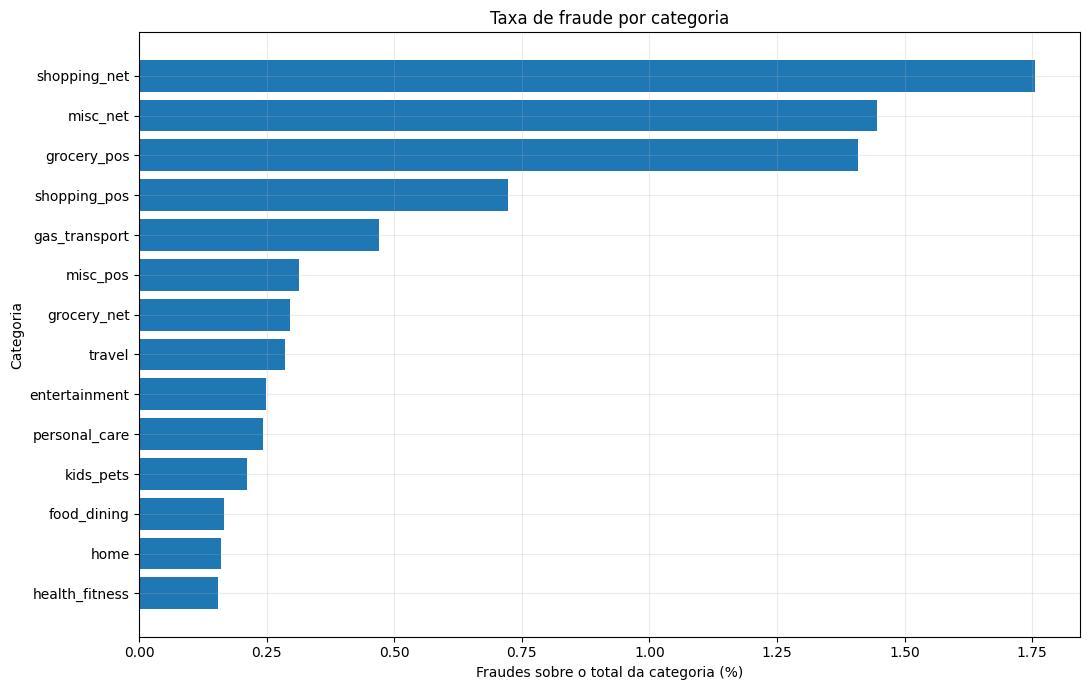

Salvo em: ../outputs/figures/01_eda_sparkov/06_taxa_fraude_por_categoria.png


In [19]:
plot = resumo_categoria.sort_values("taxa_fraude_percentual")
plt.figure(figsize=(11,7))
plt.barh(plot["category"].astype(str), plot["taxa_fraude_percentual"])
plt.title("Taxa de fraude por categoria")
plt.xlabel("Fraudes sobre o total da categoria (%)")
plt.ylabel("Categoria")
finalizar_grafico("06_taxa_fraude_por_categoria.png")

## 10. Gênero e faixa etária

In [20]:
resumo_genero = taxa_por_grupo(df_eda, "gender")
resumo_genero["gender"] = resumo_genero["gender"].astype(str).replace({"F":"Feminino","M":"Masculino"})
resumo_genero

/tmp/ipykernel_22284/3765407447.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo = (dados.groupby(coluna, dropna=False)


,gender,total_transacoes,total_fraudes,taxa_fraude_percentual
0,Feminino,709863,3735,0.5262
1,Masculino,586812,3771,0.6426


/tmp/ipykernel_22284/3765407447.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo = (dados.groupby(coluna, dropna=False)


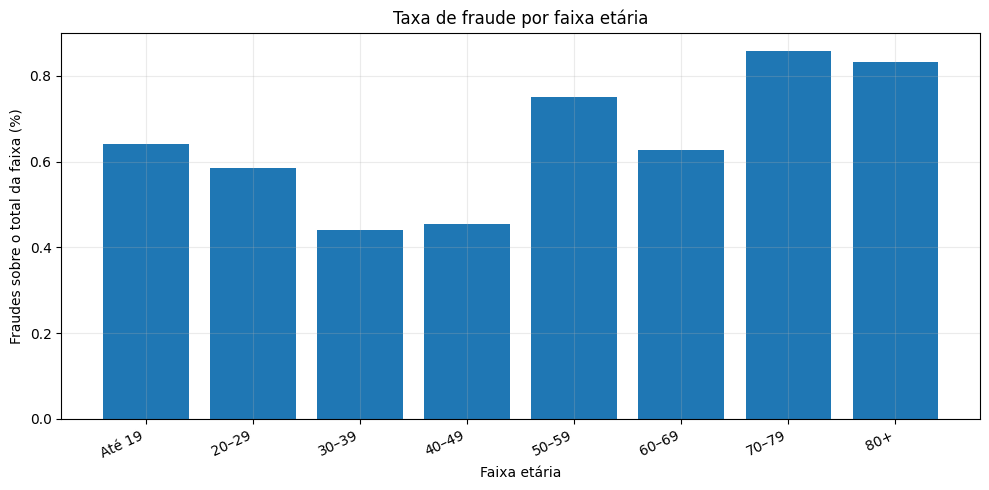

Salvo em: ../outputs/figures/01_eda_sparkov/07_taxa_fraude_por_faixa_etaria.png


In [21]:
faixas = [0,20,30,40,50,60,70,80,120]
rotulos = ["Até 19","20–29","30–39","40–49","50–59","60–69","70–79","80+"]
df_eda["faixa_etaria"] = pd.cut(df_eda["idade"], bins=faixas, labels=rotulos, right=False)
resumo_idade = taxa_por_grupo(df_eda, "faixa_etaria")

plt.figure(figsize=(10,5))
plt.bar(resumo_idade["faixa_etaria"].astype(str), resumo_idade["taxa_fraude_percentual"])
plt.title("Taxa de fraude por faixa etária")
plt.xlabel("Faixa etária")
plt.ylabel("Fraudes sobre o total da faixa (%)")
plt.xticks(rotation=25, ha="right")
finalizar_grafico("07_taxa_fraude_por_faixa_etaria.png")

## 11. Distância entre cliente e estabelecimento

In [22]:
def haversine_km(lat1, lon1, lat2, lon2):
    r = 6371.0088
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1.to_numpy(), lon1.to_numpy(), lat2.to_numpy(), lon2.to_numpy()])
    dlat, dlon = lat2-lat1, lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return r * 2*np.arctan2(np.sqrt(a), np.sqrt(1-a))

df_eda["distancia_km"] = haversine_km(df_eda["lat"], df_eda["long"], df_eda["merch_lat"], df_eda["merch_long"])

df_eda.groupby("is_fraud")["distancia_km"].agg(["count","mean","median","min","max"])

,count,mean,median,min,max
is_fraud,,,,,
0,1289169,76.1139,78.2331,0.0223,152.1174
1,7506,76.2684,77.9321,0.7388,144.5226


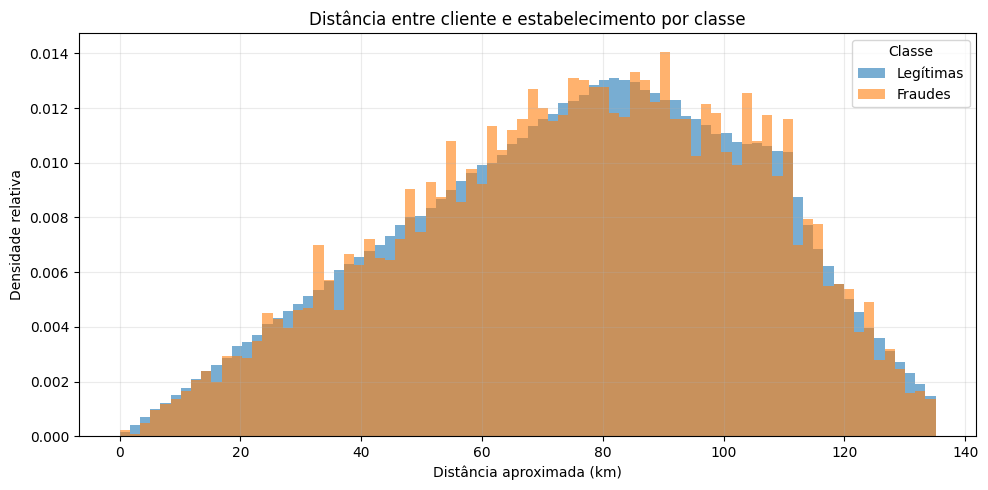

Salvo em: ../outputs/figures/01_eda_sparkov/08_distribuicao_distancia.png


In [23]:
d0 = df_eda.loc[df_eda["is_fraud"]==0, "distancia_km"]
d1 = df_eda.loc[df_eda["is_fraud"]==1, "distancia_km"]
limite = df_eda["distancia_km"].quantile(.995)
plt.figure(figsize=(10,5))
plt.hist(d0, bins=80, range=(0,limite), density=True, alpha=.6, label="Legítimas")
plt.hist(d1, bins=80, range=(0,limite), density=True, alpha=.6, label="Fraudes")
plt.title("Distância entre cliente e estabelecimento por classe")
plt.xlabel("Distância aproximada (km)")
plt.ylabel("Densidade relativa")
plt.legend(title="Classe")
finalizar_grafico("08_distribuicao_distancia.png")

## 12. Estado e comerciante com controle de volume

In [24]:
MIN_ESTADO = 5_000
estado = taxa_por_grupo(df_eda, "state", MIN_ESTADO).sort_values("taxa_fraude_percentual", ascending=False).head(15)
estado

/tmp/ipykernel_22284/3765407447.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumo = (dados.groupby(coluna, dropna=False)


,state,total_transacoes,total_fraudes,taxa_fraude_percentual
32,NV,5607,47,0.8382
5,CO,13880,113,0.8141
36,OR,18597,149,0.8012
41,TN,17554,140,0.7975
28,NE,24168,180,0.7448
20,ME,16505,119,0.7210
29,NH,8278,59,0.7127
34,OH,46480,321,0.6906
15,KS,22996,156,0.6784
44,VA,29250,198,0.6769


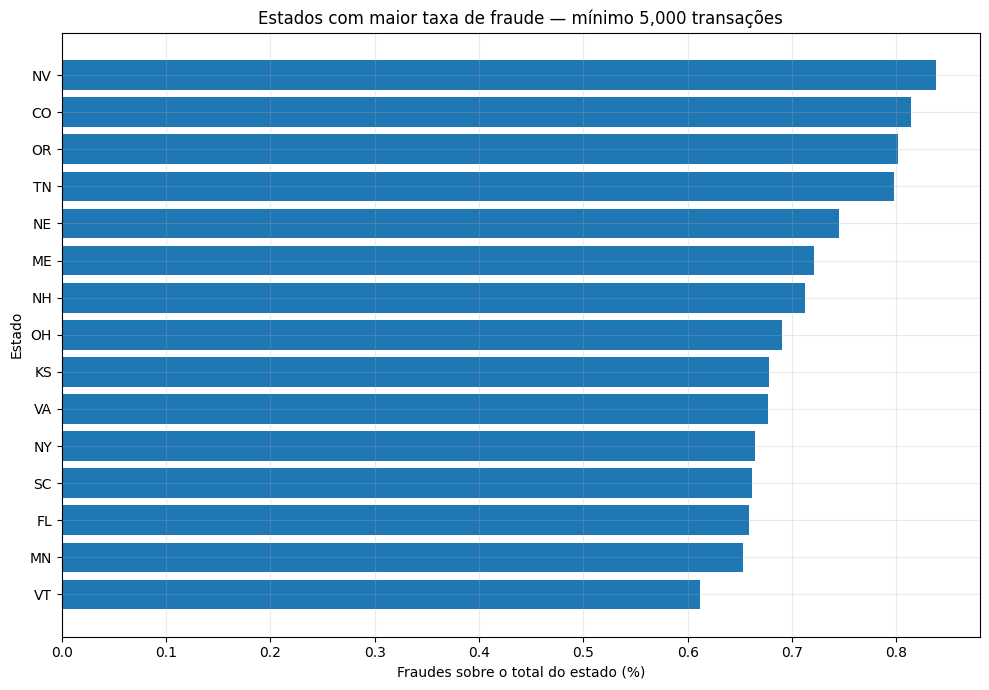

Salvo em: ../outputs/figures/01_eda_sparkov/09_top_estados_taxa_fraude.png


In [25]:
plot = estado.sort_values("taxa_fraude_percentual")
plt.figure(figsize=(10,7))
plt.barh(plot["state"].astype(str), plot["taxa_fraude_percentual"])
plt.title(f"Estados com maior taxa de fraude — mínimo {MIN_ESTADO:,} transações")
plt.xlabel("Fraudes sobre o total do estado (%)")
plt.ylabel("Estado")
finalizar_grafico("09_top_estados_taxa_fraude.png")

In [26]:
MIN_MERCHANT = 1_000
merchant = taxa_por_grupo(df_eda, "merchant", MIN_MERCHANT).sort_values("taxa_fraude_percentual", ascending=False).head(15)
merchant

,merchant,total_transacoes,total_fraudes,taxa_fraude_percentual
337,fraud_Kozey-Boehm,1866,48,2.5723
245,"fraud_Herman, Treutel and Dickens",1300,33,2.5385
304,fraud_Kerluke-Abshire,1838,41,2.2307
79,fraud_Brown PLC,1176,26,2.2109
200,fraud_Goyette Inc,1943,42,2.1616
616,fraud_Terry-Huel,1996,43,2.1543
282,fraud_Jast Ltd,1953,42,2.1505
555,"fraud_Schmeler, Bashirian and Price",1968,41,2.0833
72,fraud_Boyer-Reichert,1908,38,1.9916
372,"fraud_Langworth, Boehm and Gulgowski",1969,39,1.9807


## 13. Correlação entre variáveis numéricas interpretáveis

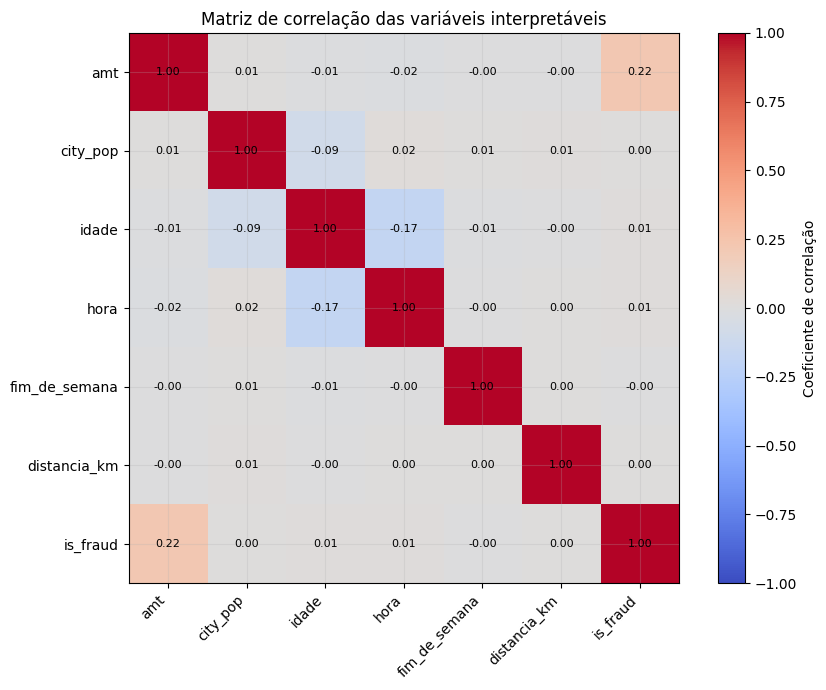

Salvo em: ../outputs/figures/01_eda_sparkov/10_heatmap_correlacoes.png


In [27]:
corr_cols = ["amt","city_pop","idade","hora","fim_de_semana","distancia_km","is_fraud"]
corr = df_eda[corr_cols].copy()
corr["fim_de_semana"] = corr["fim_de_semana"].astype(int)
matriz = corr.corr()

plt.figure(figsize=(9,7))
im = plt.imshow(matriz, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im, label="Coeficiente de correlação")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{matriz.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Matriz de correlação das variáveis interpretáveis")
finalizar_grafico("10_heatmap_correlacoes.png")

## 14. Exportação dos resumos

In [28]:
resumo_final = pd.DataFrame({
    "indicador": [
        "transacoes", "colunas_originais", "data_inicial", "data_final",
        "cartoes_distintos", "comerciantes_distintos", "categorias_distintas",
        "legitimas", "fraudes", "percentual_fraudes", "razao_legitimas_por_fraude",
        "valores_nulos", "linhas_duplicadas", "trans_num_duplicados"
    ],
    "valor": [
        len(df), df.shape[1], inicio, fim, df["cc_num"].nunique(),
        df["merchant"].nunique(), df["category"].nunique(), legitimas, fraudes,
        percentual_fraudes, razao, total_nulos, duplicados_linha, duplicados_transacao
    ]
})

resumo_final.to_csv(TABLES_PATH / "resumo_final.csv", index=False, encoding="utf-8-sig")
resumo_mes.to_csv(TABLES_PATH / "resumo_mensal.csv", index=False, encoding="utf-8-sig")
resumo_hora.to_csv(TABLES_PATH / "resumo_horario.csv", index=False, encoding="utf-8-sig")
resumo_categoria.to_csv(TABLES_PATH / "resumo_categoria.csv", index=False, encoding="utf-8-sig")
resumo_amt.to_csv(TABLES_PATH / "resumo_amt.csv", encoding="utf-8-sig")
resumo_final

,indicador,valor
0,transacoes,1296675
1,colunas_originais,22
2,data_inicial,2019-01-01 00:00:18
3,data_final,2020-06-21 12:13:37
4,cartoes_distintos,983
5,comerciantes_distintos,693
6,categorias_distintas,14
7,legitimas,1289169
8,fraudes,7506
9,percentual_fraudes,0.5789


# 15. Roteiro de interpretação manual

Após executar o notebook, responda no próprio arquivo:

1. Quantas transações e variáveis existem?
2. Qual período a base cobre?
3. Há nulos, linhas duplicadas ou `trans_num` repetidos?
4. Qual é a porcentagem de fraudes e a proporção entre classes?
5. Qual seria a acurácia de prever tudo como legítimo? Por que ela é enganosa?
6. As distribuições de `amt` diferem entre as classes? Há sobreposição?
7. A taxa de fraude varia por mês, hora ou dia da semana?
8. Quais categorias apresentam maior taxa de fraude?
9. Essas categorias também possuem volume relevante?
10. Idade, gênero ou distância parecem apresentar diferenças relevantes?
11. Rankings por estado e comerciante permanecem relevantes após exigir volume mínimo?
12. Quais variáveis parecem promissoras para a próxima etapa?

## Cuidados para a modelagem futura

- Não usar nomes, endereços ou `trans_num` como variáveis diretas.
- Não tratar `cc_num` como número contínuo.
- Criar variáveis históricas sem utilizar transações futuras.
- Separar treino e teste respeitando a ordem temporal.
- Ajustar encoders e transformações somente no conjunto de treino.
- Não aplicar balanceamento antes da separação dos conjuntos.
- Escolher métricas adequadas ao forte desbalanceamento.

## Modelo de conclusão inicial

> O dataset analisado contém **[N] transações**, registradas entre **[DATA INICIAL]** e **[DATA FINAL]**. A avaliação de qualidade identificou **[N] valores nulos**, **[N] linhas duplicadas** e **[N] identificadores de transação repetidos**.
>
> A classe fraude representa **[X]%** da base, equivalente a aproximadamente uma fraude para cada **[N] transações legítimas**. Uma estratégia que classificasse todas as transações como legítimas alcançaria acurácia de **[X]%**, mas não identificaria nenhuma fraude.
>
> A análise exploratória mostrou **[DESCREVER AMOUNT]**, **[DESCREVER PADRÃO TEMPORAL]** e **[DESCREVER CATEGORIAS]**. Os resultados sugerem que a identificação das fraudes deverá combinar múltiplas características, em vez de depender de uma única variável.
>
> A próxima etapa será definir a estratégia de preparação dos dados, divisão temporal, métricas e baseline.